# From ring widths to LiPD — a full dplPy workflow

This notebook walks the **entire** dplPy pipeline on a single collection, from raw
ring widths to a standards-compliant **LiPD** (Linked Paleo Data) file:

1. read the ring widths,
2. look at per-series **statistics** and a **summary**,
3. **detrend** to ring-width indices (RWI),
4. build **standard / residual / ARSTAN** chronologies with `chron_ars`,
5. assess chronology quality — running **rbar**, **EPS**, and **SSS**,
6. attach **site metadata**, and
7. **export to LiPD** with `to_lipd()`, then read it back with `from_lipd()` to
   close the loop.

The dataset is **Campito Mountain** bristlecone pine (*Pinus longaeva*), ITRDB
`ca533` — one of the collections shipped with dplPy. Everything here uses only
`dplpy`; the final LiPD step also needs the optional `pylipd` dependency
(`pip install "dplpy[lipd]"`).

In [1]:
import os, tempfile, zipfile, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import dplpy as dpl

warnings.filterwarnings("ignore")
pd.set_option("display.width", 140)
try:
    print("dplpy version:", dpl.__version__)
except Exception:
    pass

RWL = "../tests/data/rwl/ca533.rwl"      # Campito Mountain, ITRDB ca533

dplpy version: 0.4.0


## 1 · Read the ring widths

`dpl.readers()` reads a Tucson `.rwl` (or CSV) into a year-indexed DataFrame — one
column per measured series, `NaN` outside each series' span.

In [2]:
rwl = dpl.readers(RWL)
print("shape:", rwl.shape, " (years x series)")
print("period:", int(rwl.index.min()), "to", int(rwl.index.max()),
      "|", rwl.shape[1], "series")
rwl.iloc[:5, :5]

ca533.rwl successfully extracted as rwl file with 34 series covering the period from 626 to 1983
shape: (1358, 34)  (years x series)
period: 626 to 1983 | 34 series


,CAM011,CAM021,CAM031,CAM032,CAM041
Year,,,,,
626,NaN,NaN,NaN,NaN,NaN
627,NaN,NaN,NaN,NaN,NaN
628,NaN,NaN,NaN,NaN,NaN
629,NaN,NaN,NaN,NaN,NaN
630,NaN,NaN,NaN,NaN,NaN


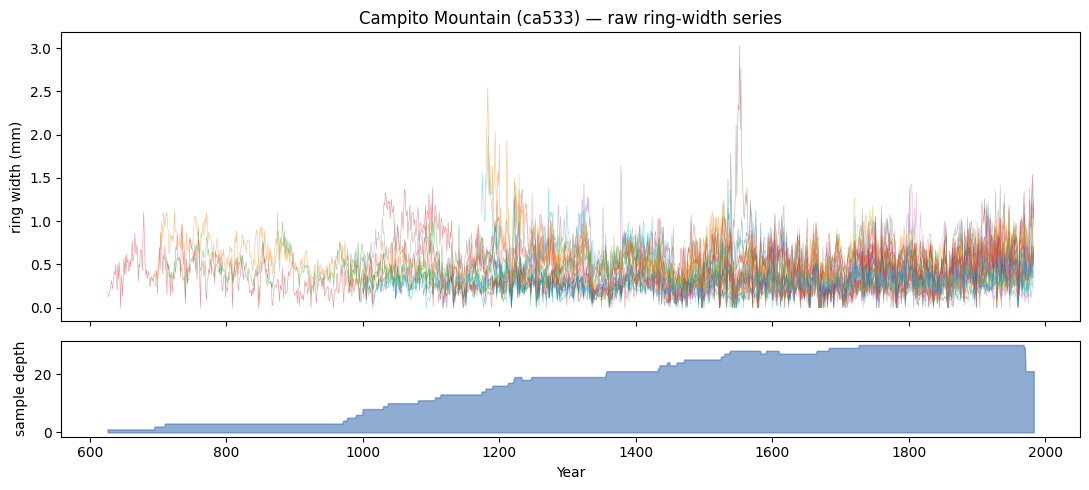

In [3]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 5), sharex=True,
                               gridspec_kw={"height_ratios": [3, 1]})
for s in rwl.columns:
    ax1.plot(rwl.index, rwl[s], lw=0.4, alpha=0.5)
ax1.set_ylabel("ring width (mm)")
ax1.set_title("Campito Mountain (ca533) — raw ring-width series")
ax2.fill_between(rwl.index, rwl.notna().sum(axis=1), color="#4575b4", alpha=0.6)
ax2.set_ylabel("sample depth"); ax2.set_xlabel("Year")
plt.tight_layout(); plt.show()

## 2 · Per-series statistics and a summary

`dpl.stats()` reports the standard per-series descriptive statistics (span, mean,
median, stdev, skew, kurtosis, gini, ar1); `dpl.summary()` gives a compact
`describe`-style table with the series as columns.

In [4]:
stats = dpl.stats(rwl)
stats.head(8)

,series,first,last,year,mean,median,stdev,skew,kurtosis,gini,ar1
1,CAM011,1530,1983,454,0.440,0.40,0.222,1.029,1.102,0.273,0.696
2,CAM021,1433,1983,551,0.424,0.40,0.185,0.946,1.110,0.237,0.701
3,CAM031,1356,1983,628,0.349,0.29,0.214,0.690,-0.366,0.341,0.808
4,CAM032,1435,1983,549,0.293,0.26,0.163,0.717,0.159,0.309,0.661
5,CAM041,1683,1983,301,0.526,0.53,0.223,0.488,0.098,0.238,0.690
6,CAM042,1538,1983,446,0.439,0.36,0.348,3.678,17.713,0.324,0.880
7,CAM051,1247,1983,737,0.273,0.25,0.140,1.836,6.678,0.262,0.705
8,CAM061,1357,1983,627,0.462,0.47,0.202,-0.111,-0.223,0.247,0.509


In [5]:
summary = dpl.summary(rwl)
summary

,CAM011,CAM021,CAM031,CAM032,CAM041,CAM042,CAM051,CAM061,CAM062,CAM071,...,CAM151,CAM152,CAM161,CAM162,CAM171,CAM172,CAM181,CAM191,CAM201,CAM211
count,454.000000,551.000000,628.000000,549.000000,301.000000,446.000000,737.000000,627.000000,459.000000,947.000000,...,749.000000,229.000000,504.000000,1000.000000,758.000000,797.000000,781.000000,791.000000,593.000000,1343.000000
mean,0.439581,0.424465,0.349156,0.293224,0.525648,0.439148,0.273012,0.462281,0.441939,0.249071,...,0.445648,0.533799,0.339464,0.396710,0.450264,0.482296,0.282638,0.366271,0.473929,0.356813
std,0.221801,0.185397,0.213666,0.162930,0.222568,0.347705,0.139691,0.201785,0.188389,0.109357,...,0.272561,0.194947,0.148916,0.184057,0.209848,0.249002,0.148853,0.335788,0.180967,0.182086
min,0.000000,0.050000,0.000000,0.000000,0.100000,0.070000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.060000,0.000000,0.000000,0.080000,0.080000,0.000000,0.000000,0.000000,0.000000
25%,0.290000,0.290000,0.180000,0.180000,0.350000,0.270000,0.180000,0.335000,0.330000,0.180000,...,0.240000,0.410000,0.230000,0.260000,0.300000,0.310000,0.170000,0.170000,0.350000,0.220000
50%,0.400000,0.400000,0.290000,0.260000,0.530000,0.360000,0.250000,0.470000,0.450000,0.250000,...,0.390000,0.520000,0.330000,0.370000,0.400000,0.420000,0.250000,0.250000,0.470000,0.340000
75%,0.540000,0.520000,0.510000,0.390000,0.680000,0.460000,0.330000,0.600000,0.580000,0.320000,...,0.610000,0.660000,0.430000,0.510000,0.580000,0.590000,0.380000,0.455000,0.580000,0.470000
max,1.360000,1.110000,1.030000,0.850000,1.380000,3.030000,1.320000,1.090000,0.920000,0.620000,...,1.640000,1.250000,0.900000,1.040000,1.540000,1.980000,0.800000,2.540000,1.490000,1.100000


## 3 · Detrend to ring-width indices (RWI)

Detrending removes each series' age/size-related growth trend, leaving a
dimensionless ring-width index centred on ~1.0. Here we use a cubic smoothing
spline with the ratio method (dplR's default flavour).

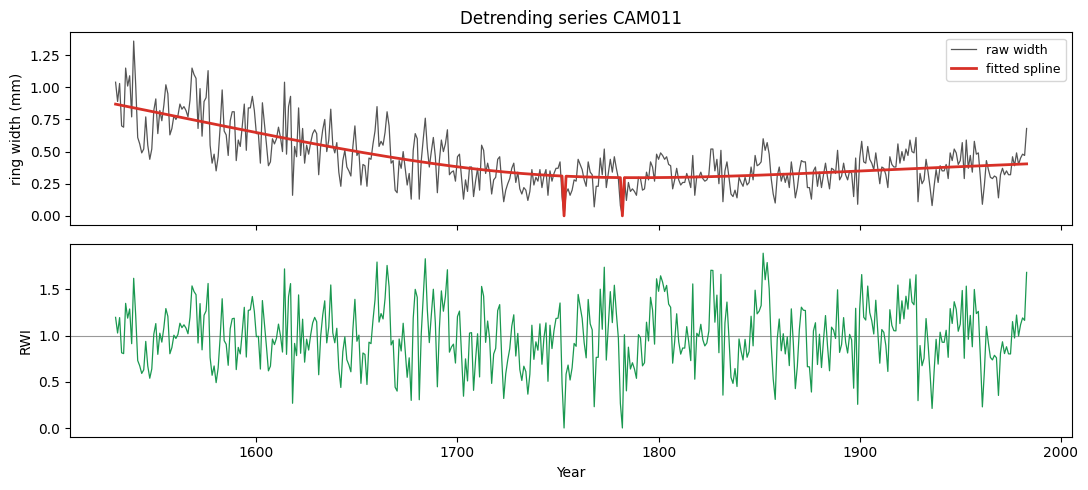

In [6]:
rwi = dpl.detrend(rwl, fit="Spline", method="ratio", plot=False)

# show one series: raw width, the fitted spline (raw / rwi), and the resulting RWI
s = rwl.columns[0]
fig, (axa, axb) = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
axa.plot(rwl.index, rwl[s], lw=0.9, color="#555555", label="raw width")
curve = (rwl[s] / rwi[s])
axa.plot(curve.index, curve, lw=2.0, color="#d73027", label="fitted spline")
axa.set_ylabel("ring width (mm)"); axa.legend(loc="upper right", fontsize=9)
axa.set_title(f"Detrending series {s}")
axb.axhline(1.0, color="#999999", lw=0.8)
axb.plot(rwi.index, rwi[s], lw=0.9, color="#1a9850")
axb.set_ylabel("RWI"); axb.set_xlabel("Year")
plt.tight_layout(); plt.show()

## 4 · Build the chronologies (`chron_ars`)

`dpl.chron_ars()` produces the three ARSTAN-style chronologies at once from the
RWI: the **standard** chronology (a robust biweight mean of the indices), the
**residual** chronology (after AR prewhitening removes autocorrelation), and the
**ARSTAN** chronology (the residual signal with pooled autoregression added back).
It returns them alongside the per-year sample depth.

In [7]:
ars = dpl.chron_ars(rwi, verbose=False)
print("columns:", list(ars.columns))
ars.head()

columns: ['std', 'res', 'ars', 'samp_depth']


,std,res,ars,samp_depth
Year,,,,
626,0.371562,NaN,NaN,1
627,0.284366,NaN,NaN,1
628,0.306488,NaN,NaN,1
629,0.416286,NaN,NaN,1
630,0.482406,NaN,NaN,1


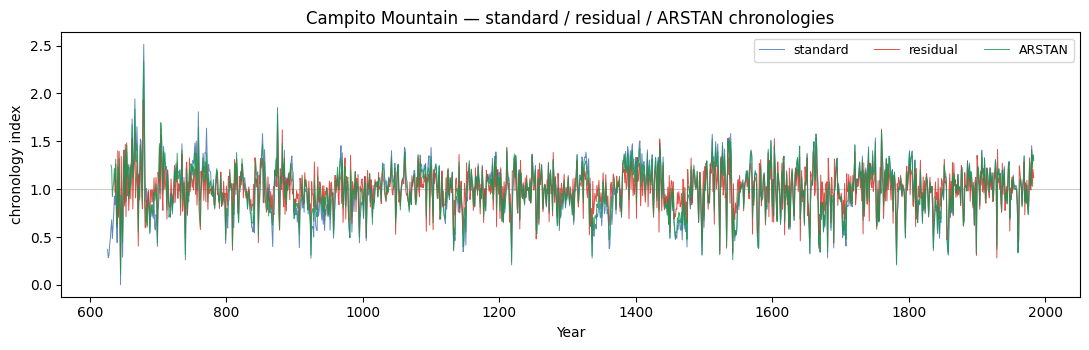

In [8]:
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.axhline(1.0, color="#cccccc", lw=0.8)
for col, color, lab in [("std", "#4575b4", "standard"),
                        ("res", "#d73027", "residual"),
                        ("ars", "#1a9850", "ARSTAN")]:
    ax.plot(ars.index, ars[col], lw=0.7, color=color, alpha=0.85, label=lab)
ax.set_ylabel("chronology index"); ax.set_xlabel("Year")
ax.set_title("Campito Mountain — standard / residual / ARSTAN chronologies")
ax.legend(loc="upper right", ncol=3, fontsize=9)
plt.tight_layout(); plt.show()

## 5 · Chronology quality: rbar, EPS, and SSS

How well-replicated and coherent is the chronology through time?

- **rbar** — the mean interseries correlation (how similarly the series vary).
- **EPS** (expressed population signal) — how well the finite sample represents the
  theoretical population chronology; the customary adequacy threshold is **0.85**.
- **SSS** (subsample signal strength) — how well a reduced sample depth reproduces
  the full-sample chronology, i.e. how far back the chronology stays trustworthy.

`dpl.rwi_stats()` gives the whole-record figures; `dpl.rwi_stats_running()` gives
them in moving windows; `dpl.chron_stabilized(running_rbar=True)` gives a per-year
running rbar; and `dpl.sss()` gives the per-year SSS.

In [9]:
overall = dpl.rwi_stats(rwi)
print(f"whole-record:  rbar_eff = {float(overall['rbar_eff'].iloc[0]):.3f}"
      f"   EPS = {float(overall['eps'].iloc[0]):.3f}"
      f"   SNR = {float(overall['snr'].iloc[0]):.2f}"
      f"   (n = {int(overall['n'].iloc[0])} series)")

run  = dpl.rwi_stats_running(rwi)                       # windowed EPS / rbar
stab = dpl.chron_stabilized(rwi, running_rbar=True)     # per-year running rbar
sss  = dpl.sss(rwi)                                     # per-year SSS
run[["start_year", "mid_year", "end_year", "n", "rbar_eff", "eps"]].head()

whole-record:  rbar_eff = 0.423   EPS = 0.961   SNR = 24.88   (n = 34 series)
Generating variance stabilized chronology...



SUCCESS!



,start_year,mid_year,end_year,n,rbar_eff,eps
0,626,650,675,0,NaN,NaN
1,651,675,700,0,NaN,NaN
2,676,700,725,2,0.266,0.420
3,701,725,750,3,0.408,0.674
4,726,750,775,3,0.298,0.560


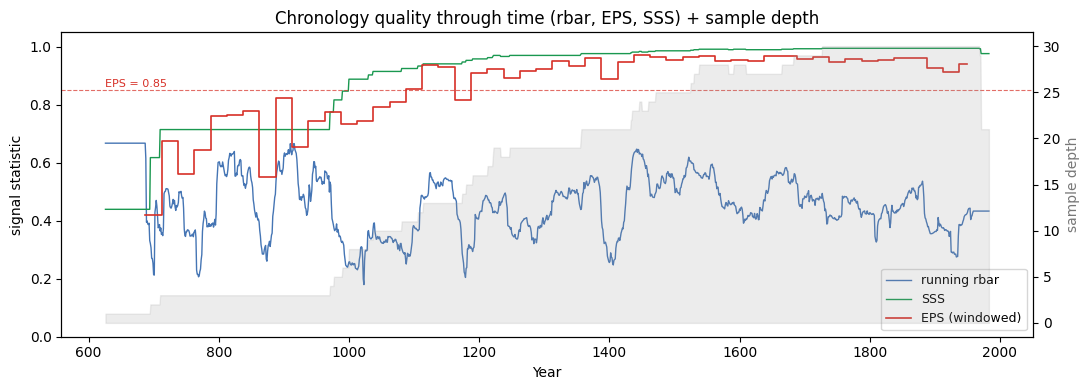

In [10]:
depth = rwl.notna().sum(axis=1)
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(stab.index, stab["Running rbar"], color="#4575b4", lw=1.0, label="running rbar")
ax.plot(sss.index, sss.values, color="#1a9850", lw=1.0, label="SSS")
ax.step(run["mid_year"], run["eps"], where="mid", color="#d73027", lw=1.2,
        label="EPS (windowed)")
ax.axhline(0.85, color="#d73027", ls="--", lw=0.8, alpha=0.7)
ax.text(rwl.index.min(), 0.86, "EPS = 0.85", color="#d73027", fontsize=8)
ax.set_ylabel("signal statistic"); ax.set_xlabel("Year"); ax.set_ylim(0, 1.05)
ax.legend(loc="lower right", fontsize=9)
axd = ax.twinx()
axd.fill_between(depth.index, depth.values, color="#999999", alpha=0.18)
axd.set_ylabel("sample depth", color="#777777")
ax.set_title("Chronology quality through time (rbar, EPS, SSS) + sample depth")
plt.tight_layout(); plt.show()

The signal statistics rise as more cores contribute and fall in the sparsely
replicated early years — the standard picture for deciding how far back a
chronology is well-expressed.

## 6 · Site metadata

LiPD records carry site metadata (coordinates, elevation, species, investigators).
dplPy keeps these in a `SiteMetadata` object. When a `.rwl` has an ITRDB header,
`dpl.SiteMetadata.from_rwl(rwl)` fills it automatically; `ca533` here ships without
one, so we supply the Campito Mountain details by hand.

In [11]:
meta = dpl.SiteMetadata(
    site_id="ca533",
    site_name="Campito Mountain",
    species_code="PILO",
    species_name="Pinus longaeva",
    country_region="USA",
    latitude=37.5,
    longitude=-118.2,
    elevation_m=3400,
    investigators="LaMarche, V.C.; Graybill, D.A.",
)
meta

SiteMetadata(site_id='ca533', site_name='Campito Mountain', species_code='PILO', species_name='Pinus longaeva', country_region='USA', elevation_m=3400, latitude=37.5, longitude=-118.2, first_year=None, last_year=None, investigators='LaMarche, V.C.; Graybill, D.A.')

## 7 · Export to LiPD (`to_lipd`)

`dpl.to_lipd()` writes everything into a single `.lpd` container. Following dplPy's
convention, the **standard chronology becomes the primary measurement** (so LiPD
tools return it by default), the **residual and ARSTAN** chronologies are written
alongside (`chronologies="all"`), the running **rbar/EPS** ride on the primary
table (`stats=`), the raw ring widths go in their own table (`rwl=`), and the
`provenance` and `publication` document how the record was made.

In [12]:
outdir = tempfile.mkdtemp()
lpd_path = dpl.to_lipd(
    ars, os.path.join(outdir, "CampitoMountain.ca533"),
    rwl=rwl,
    metadata=meta,
    chronologies="all",                 # standard + residual + ARSTAN
    stats=stab,                         # running rbar -> RBAR/EPS on the primary
    provenance=("Cubic smoothing spline detrend (ratio); robust biweight mean; "
                "residual & ARSTAN chronologies via chron_ars"),
    publication={"authors": "LaMarche, V.C.; Graybill, D.A.", "year": 1991,
                 "title": "Campito Mountain bristlecone pine ring-width chronology"},
)
print("wrote:", os.path.basename(lpd_path), f"({os.path.getsize(lpd_path):,} bytes)")

# a .lpd is a zipped BagIt container: metadata.jsonld + one CSV per data table
with zipfile.ZipFile(lpd_path) as z:
    for n in sorted(x for x in z.namelist() if not x.endswith("/")):
        print("   ", n.split("data/")[-1] if "data/" in n else n.split("/")[-1])

wrote: CampitoMountain.ca533.lpd (407,866 bytes)
    bag-info.txt
    bagit.txt
    CampitoMountain-ca533.paleo1measurement1.csv
    CampitoMountain-ca533.paleo1measurement2.csv
    CampitoMountain-ca533.paleo1measurement3.csv
    CampitoMountain-ca533.paleo1measurement4.csv
    metadata.jsonld
    manifest-md5.txt
    tagmanifest-md5.txt


## 8 · Read it back (`from_lipd`) — closing the loop

`dpl.from_lipd()` turns a `.lpd` back into dplPy-native objects: the raw ring
widths as an RWL, every chronology it finds, and the site metadata. We confirm the
data survived the round trip.

In [13]:
back = dpl.from_lipd(lpd_path)
print("dataset:", back["dsname"])
print("chronologies recovered:", list(back["chronologies"]))
print("RWL recovered:", back["rwl"].shape, "(matches original:",
      back["rwl"].shape == rwl.shape, ")")

# raw widths round-trip exactly; the standard chronology to machine precision
cols = [c for c in rwl.columns if c in back["rwl"].columns]
a, b = rwl[cols].align(back["rwl"][cols], join="inner", axis=0)
m = a.notna() & b.notna()
print(f"raw ring width  max|diff| = {np.nanmax((a - b).abs().where(m).values):.2e}")
sa, sb = ars["std"].align(back["chronologies"]["standard"]["trsgi"], join="inner")
mm = sa.notna() & sb.notna()
print(f"standard chron  max|diff| = {np.nanmax((sa - sb).abs().where(mm).values):.2e}")
print("\nmetadata read back:",
      {k: back["metadata"][k] for k in ("site_id", "site_name", "latitude",
                                        "longitude", "elevation_m", "investigators")})

Loading 1 LiPD files


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00, 11.67it/s]

Loaded..


dataset: CampitoMountain.ca533
chronologies recovered: ['residual', 'standard', 'arstan']
RWL recovered: (1358, 34) (matches original: True )
raw ring width  max|diff| = 0.00e+00
standard chron  max|diff| = 2.22e-16

metadata read back: {'site_id': 'ca533', 'site_name': 'Campito Mountain', 'latitude': 37.5, 'longitude': -118.2, 'elevation_m': 3400.0, 'investigators': 'V.C. LaMarche; D.A. Graybill'}


## What we built

In a handful of `dplpy` calls we went from raw ring widths to a complete,
interoperable LiPD record:

`readers` → `stats` / `summary` → `detrend` → `chron_ars` →
`rwi_stats` / `rwi_stats_running` / `chron_stabilized` / `sss` →
`SiteMetadata` → **`to_lipd`** (and back with `from_lipd`).

The resulting `.lpd` carries the standard chronology as its primary series (with
running rbar/EPS), the residual and ARSTAN chronologies, the raw ring widths, the
site geo/metadata, a citation, and a provenance note — ready to share on the
LinkedEarth / lipdverse ecosystem or hand to `pylipd` / Pyleoclim. Point `RWL` at
any other collection to run the same workflow end to end.